# Module 7: Forecasting Regional Time Series

**Unit D · Week 7** · Track 2 — Visualization, Analytic Hubs & Responsible AI

Small-N regional data rarely supports anything fancier than exponential smoothing, and the chart must always carry a confidence interval, never a bare point forecast. Both languages below use the same method (Holt-Winters exponential smoothing) so the outputs are directly comparable; if you have Prophet installed, the commented cell shows the same forecast that way instead.

## Learning objectives

- **Foundational** _Understand_ — Distinguish trend from seasonality in a time series; explain when machine learning is, and is not, appropriate for small-N regional data.
- **Intermediate** _Apply_ — Produce a forecast with a visible confidence interval.

## Setup

This notebook reads `../../data/processed/track2_dataset.csv`, built by
`data/make_sample_data.py`. It is **synthetic** data shaped like the real
NISR/HDX handoff described in the course site's Chapter 3 — swap in a real
extract by re-pointing the path below once you have one. See
`data/README.md` for where to get real data and exactly what to rename.


In [1]:
import pandas as pd

DATA_PATH = "../../data/processed/track2_dataset.csv"
df = pd.read_csv(DATA_PATH, parse_dates=["date"])
print(f"{len(df):,} rows · {df['district'].nunique()} districts · "
      f"{df['date'].min().date()} to {df['date'].max().date()}")
df.head()

240 rows · 10 districts · 2023-01-01 to 2024-12-01


,date,province,district,district_pcode,indicator,value,feature_1,feature_2,outcome
0,2023-01-01,Kigali City,Gasabo,SIM-GAS,sample_wellbeing_index,39.37,82.01,19.22,1
1,2023-02-01,Kigali City,Gasabo,SIM-GAS,sample_wellbeing_index,45.24,49.99,17.62,1
2,2023-03-01,Kigali City,Gasabo,SIM-GAS,sample_wellbeing_index,41.16,46.66,19.93,0
3,2023-04-01,Kigali City,Gasabo,SIM-GAS,sample_wellbeing_index,42.91,49.17,20.35,0
4,2023-05-01,Kigali City,Gasabo,SIM-GAS,sample_wellbeing_index,42.05,51.04,20.35,0


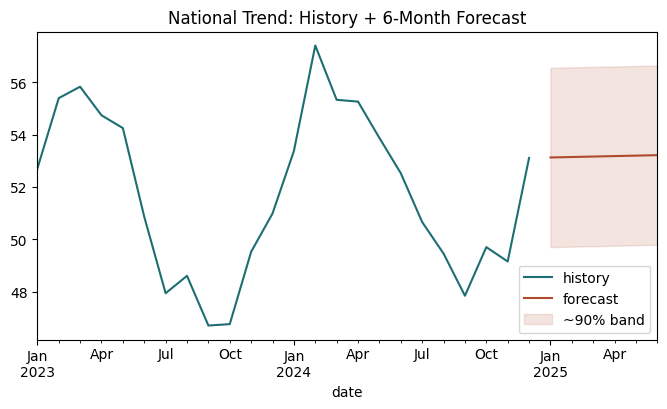

In [2]:
import pandas as pd
from statsmodels.tsa.holtwinters import ExponentialSmoothing

ts = df.groupby("date")["value"].mean().asfreq("MS").interpolate()

fit = ExponentialSmoothing(ts, trend="add", seasonal=None).fit()
horizon = 6
forecast = fit.forecast(horizon)
resid_std = fit.resid.std()
ci = 1.645 * resid_std  # ~90% band from in-sample residual spread

ax = ts.plot(figsize=(8, 4), label="history", color="#1D6E73")
forecast.plot(ax=ax, label="forecast", color="#AF4A2E")
ax.fill_between(forecast.index, forecast - ci, forecast + ci, color="#AF4A2E", alpha=0.15, label="~90% band")
ax.legend()
ax.set_title("National Trend: History + 6-Month Forecast")
import matplotlib.pyplot as plt
plt.show()

# --- Prophet alternative (if installed) ---
# from prophet import Prophet
# prophet_df = ts.reset_index().rename(columns={"date": "ds", "value": "y"})
# m = Prophet(interval_width=0.90).fit(prophet_df)
# future = m.make_future_dataframe(periods=horizon, freq="MS")
# m.plot(m.predict(future))

## Your turn

Forecast one time series from the dataset in both languages; the chart must show history, forecast, and confidence interval together. Then repeat for a second district and compare.

**Formative assessment.** Feeds into the combined Module 7 to 8 forecast and model report (see Module 8).

## Responsible AI callback

A forecast presented without its confidence interval is a governance issue, not a style choice. It misrepresents certainty to a decision-maker who may act on it.